In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Check the attenuation curves look reasonable

Dataset: train, number of entries: 72177
Number of unique wavelengths: 49
Dataset: val, number of entries: 36064
Number of unique wavelengths: 49
Dataset: test, number of entries: 36064
Number of unique wavelengths: 49


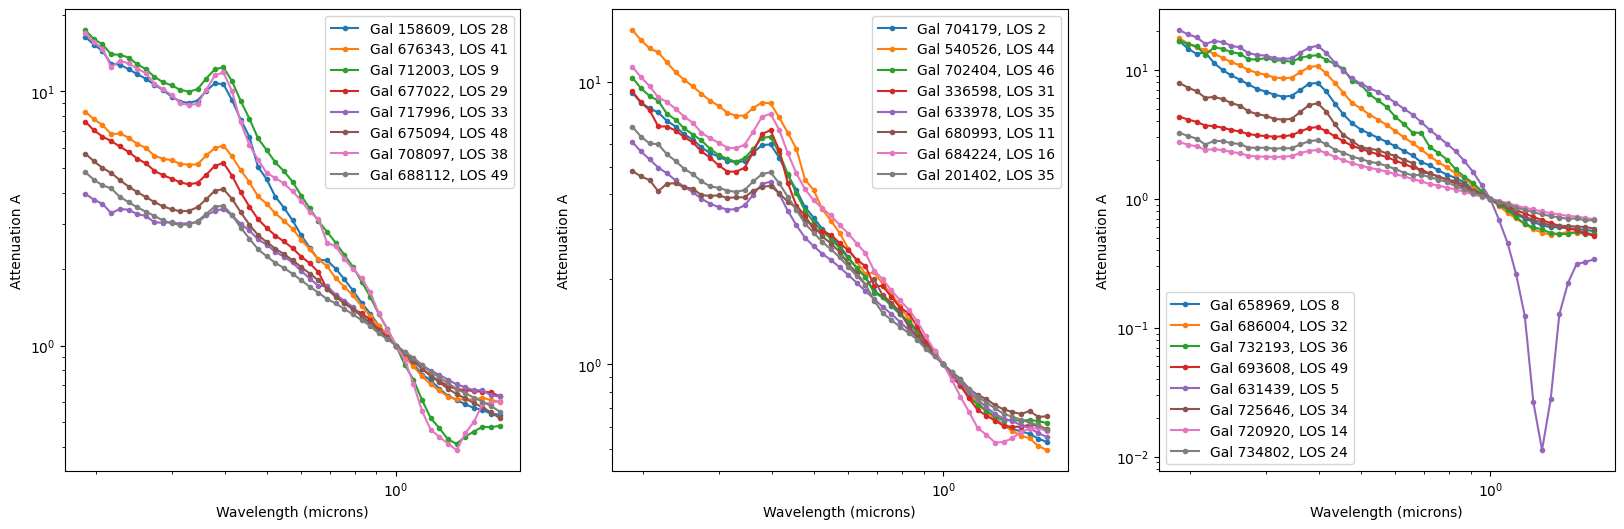

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
nplot = 8

for name, ax in zip(['train', 'val', 'test'], axs):

    df = pd.read_csv(f'../data/iob_data_0/iob_{name}_data.txt', sep=r'\s+')
    print(f"Dataset: {name}, number of entries: {len(df)}")
    nlam = len(set(df['lam']))
    print(f"Number of unique wavelengths: {nlam}")

    galaxy_ids = df['galaxy_id'].unique()
    for i in range(nplot):
        gid = galaxy_ids[i]
        galaxy_data = df[df['galaxy_id'] == gid]
        ax.loglog(galaxy_data['lam'], galaxy_data['A'], label=f'Gal {int(gid)}, LOS {int(galaxy_data["los"].iloc[0])}', marker='.')
    ax.legend()
    ax.set_xlabel('Wavelength (microns)')
    ax.set_ylabel('Attenuation A')

# OLD

In [2]:
fname = '../data/iob_codes_plus_Acurve_with_ID_LOS.txt'
df_symreg = pd.read_csv(fname, sep='\t', comment='#')

fname = '../data/gal_los_iobcomp_attcurve_galprop.dat'
df_opt = pd.read_csv(fname, sep='\t', comment='#')

print(df_symreg.keys())
print(df_opt.keys())

if df_symreg.shape == df_opt.shape:
    print('\nSame shape for both datasets')
else:
    print('\nDatasets have different shapes!')
    print(f'Symreg shape: {df_symreg.shape}')
    print(f'Opt shape: {df_opt.shape}')

galaxy_id_symreg = np.sort(np.unique(df_symreg['galaxy_id'].values))
galaxy_id_opt = np.sort(np.unique(df_opt['galaxy_id'].values))
same = np.array_equal(galaxy_id_symreg, galaxy_id_opt)
if same:
    print('\nSame galaxy IDs in both datasets')
else:
    print('\nGalaxy IDs differ between datasets!')
    # Check for missing galaxies in either dataset
    missing_symreg = np.setdiff1d(galaxy_id_opt, galaxy_id_symreg)
    missing_opt = np.setdiff1d(galaxy_id_symreg, galaxy_id_opt)
    if len(missing_symreg) > 0:
        print(f'Missing in symreg: {len(missing_symreg)}')
    if len(missing_opt) > 0:
        print(f'Missing in opt: {len(missing_opt)}')

# Pick a galaxy and check that the los in the two files match
gid = np.intersect1d(galaxy_id_symreg, galaxy_id_opt)[0]
df_symreg_gal = df_symreg[df_symreg['galaxy_id'] == gid]
df_opt_gal = df_opt[df_opt['galaxy_id'] == gid]
los_symreg = df_symreg_gal['los'].values
los_opt = df_opt_gal['los'].values
print('\n'+str(gid))
print('los_symreg:', los_symreg)
print('los_opt:', los_opt)

Index(['galaxy_id', 'los', 'IOB1', 'IOB2', 'IOB3', 'IOB4', 'IOB5', 'IOB6',
       'IOB7', 'IOB8', 'A_1000A', 'A_1047A', 'A_1096A', 'A_1148A', 'A_1203A',
       'A_1260A', 'A_1320A', 'A_1382A', 'A_1448A', 'A_1516A', 'A_1588A',
       'A_1663A', 'A_1742A', 'A_1825A', 'A_1911A', 'A_2002A', 'A_2097A',
       'A_2196A', 'A_2300A', 'A_2409A', 'A_2523A', 'A_2643A', 'A_2768A',
       'A_2899A', 'A_3036A', 'A_3180A', 'A_3331A', 'A_3489A', 'A_3654A',
       'A_3827A', 'A_4008A', 'A_4198A', 'A_4397A', 'A_4605A', 'A_4824A',
       'A_5052A', 'A_5291A', 'A_5542A', 'A_5805A', 'A_6080A', 'A_6368A',
       'A_6669A', 'A_6985A', 'A_7316A', 'A_7663A', 'A_8026A', 'A_8406A',
       'A_8804A', 'A_9221A', 'A_9658A'],
      dtype='object')
Index(['galaxy_id', 'los', 'IOB1', 'IOB2', 'IOB3', 'IOB4', 'IOB5', 'IOB6',
       'IOB7', 'IOB8', 'A_1000A', 'A_1047A', 'A_1096A', 'A_1148A', 'A_1203A',
       'A_1260A', 'A_1320A', 'A_1382A', 'A_1448A', 'A_1516A', 'A_1588A',
       'A_1663A', 'A_1742A', 'A_1825A', 'A_1911

Number of curves with A_V > 0.7: 2181 (8.3%)
Number of curves with A_V < 0.2: 11003 (41.9%)


/tmp/ipykernel_19615/162304922.py:2: RuntimeWarning: invalid value encountered in log10
  plt.hist(np.log10(A_v), bins=50, histtype='step')


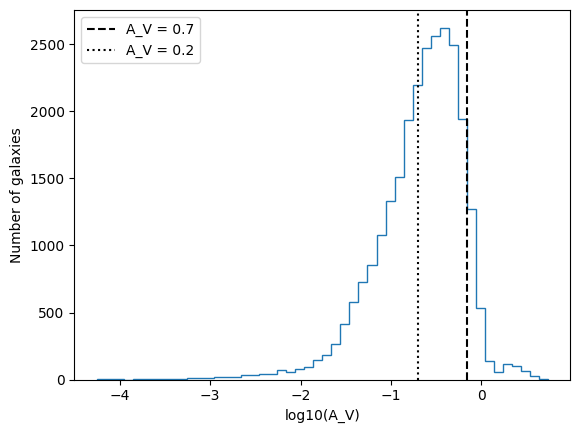

In [8]:
A_v = df_opt['A_5542A'].values
plt.hist(np.log10(A_v), bins=50, histtype='step')
plt.xlabel('log10(A_V)')
plt.ylabel('Number of galaxies')

Av_big = 0.7
plt.axvline(np.log10(Av_big), color='k', ls='--', label='A_V = 0.7')
m = A_v > Av_big
print(f'Number of curves with A_V > {Av_big}: {np.sum(m)} ({m.sum()/len(A_v)*100:.1f}%)')

Av_small = 0.2
plt.axvline(np.log10(Av_small), color='k', ls=':', label='A_V = 0.2')
m = A_v < Av_small
print(f'Number of curves with A_V < {Av_small}: {np.sum(m)} ({m.sum()/len(A_v)*100:.1f}%)')

plt.legend()